# MSA 2026 Phase 2 - Part 2: Maximum Temperature Prediction from Weather Data

## 1. Load and check the dataset

## 2. Clean the dataset, drop variables

## 3. Select the feature(s) for the model, and explain the reason

In [ ]:
I selected MinTemp and MeanTemp as the features to predict MaxTemp.

Reason: From the correlation analysis, both MinTemp and MeanTemp have a very strong positive correlation with MaxTemp. This makes sense because the minimum and average temperatures of a day are closely related to the maximum temperature. Other variables such as Precip and Snowfall had much weaker correlations, so they were not included.

## 4. Split the dataset (70% for training, 30% for testing)

## 5. Choose the algorithm, train and test the model

## 6. Evaluate and Visualize model Performance

## 7. What is the R² value and RMSE of the model? How these values indicate the model performance?

In [ ]:
R² Score: 0.985
RMSE: 1.027

The R² score of 0.985 means the model explains about 98.5% of the variation in MaxTemp. This is a very high value and shows the model fits the data extremely well.

The RMSE of 1.027 means that on average the model’s predictions are only about 1 degree away from the actual maximum temperature. This is a low error and indicates strong predictive performance.

## 8. Discuss the model performance based on the plot

In [ ]:
The scatter plot of Predicted vs Actual MaxTemp shows that most points lie very close to the red diagonal line. This means the predicted values are almost the same as the actual values. There is no clear pattern of the model consistently over-predicting or under-predicting. Overall, the plot confirms that the linear regression model performs very well on this dataset.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [30]:
# Load the weather dataset
df = pd.read_csv("Summary of Weather.csv")

print("Dataset loaded successfully!")
print("Shape of the dataset (rows, columns):", df.shape)

Dataset loaded successfully!
Shape of the dataset (rows, columns): (119040, 31)


C:\Users\sunny\AppData\Local\Temp\ipykernel_5588\2177122882.py:2: DtypeWarning: Columns (0: Snowfall, 1: PoorWeather, 2: SNF, 3: TSHDSBRSGF) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Summary of Weather.csv")


In [31]:
# Show the first 10 rows
display(df.head(10))


,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,1942-7-1,1.016,NaN,25.555556,22.222222,23.888889,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,1942-7-2,0,NaN,28.888889,21.666667,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,1942-7-3,2.54,NaN,26.111111,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,1942-7-4,2.54,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,1942-7-5,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10001,1942-7-6,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,10001,1942-7-7,T,NaN,28.333333,22.777778,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,10001,1942-7-8,3.556,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,10001,1942-7-9,T,NaN,27.222222,22.777778,25.000000,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10001,1942-7-10,3.556,NaN,25.555556,21.666667,23.333333,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# All column names
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Column names:
['STA', 'Date', 'Precip', 'WindGustSpd', 'MaxTemp', 'MinTemp', 'MeanTemp', 'Snowfall', 'PoorWeather', 'YR', 'MO', 'DA', 'PRCP', 'DR', 'SPD', 'MAX', 'MIN', 'MEA', 'SNF', 'SND', 'FT', 'FB', 'FTI', 'ITH', 'PGT', 'TSHDSBRSGF', 'SD3', 'RHX', 'RHN', 'RVG', 'WTE']

Data types:
STA              int64
Date               str
Precip             str
WindGustSpd    float64
MaxTemp        float64
MinTemp        float64
MeanTemp       float64
Snowfall        object
PoorWeather     object
YR               int64
MO               int64
DA               int64
PRCP               str
DR             float64
SPD            float64
MAX            float64
MIN            float64
MEA            float64
SNF             object
SND            float64
FT             float64
FB             float64
FTI            float64
ITH            float64
PGT            float64
TSHDSBRSGF      object
SD3            float64
RHX            float64
RHN            float64
RVG            float64
WTE            float64
dt

In [33]:
# Key statistics
display(df.describe())

,STA,WindGustSpd,MaxTemp,MinTemp,MeanTemp,YR,MO,DA,DR,SPD,...,FT,FB,FTI,ITH,PGT,SD3,RHX,RHN,RVG,WTE
count,119040.000000,532.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,533.000000,532.000000,...,0.0,0.0,0.0,0.0,525.000000,0.0,0.0,0.0,0.0,0.0
mean,29659.435795,37.774534,27.045111,17.789511,22.411631,43.805284,6.726016,15.797530,26.998124,20.396617,...,NaN,NaN,NaN,NaN,12.085333,NaN,NaN,NaN,NaN,NaN
std,20953.209402,10.297808,8.717817,8.334572,8.297982,1.136718,3.425561,8.794541,15.221732,5.560371,...,NaN,NaN,NaN,NaN,5.731328,NaN,NaN,NaN,NaN,NaN
min,10001.000000,18.520000,-33.333333,-38.333333,-35.555556,40.000000,1.000000,1.000000,2.000000,10.000000,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,11801.000000,29.632000,25.555556,15.000000,20.555556,43.000000,4.000000,8.000000,11.000000,16.000000,...,NaN,NaN,NaN,NaN,8.500000,NaN,NaN,NaN,NaN,NaN
50%,22508.000000,37.040000,29.444444,21.111111,25.555556,44.000000,7.000000,16.000000,32.000000,20.000000,...,NaN,NaN,NaN,NaN,11.600000,NaN,NaN,NaN,NaN,NaN
75%,33501.000000,43.059000,31.666667,23.333333,27.222222,45.000000,10.000000,23.000000,34.000000,23.250000,...,NaN,NaN,NaN,NaN,15.000000,NaN,NaN,NaN,NaN,NaN
max,82506.000000,75.932000,50.000000,34.444444,40.000000,45.000000,12.000000,31.000000,78.000000,41.000000,...,NaN,NaN,NaN,NaN,23.900000,NaN,NaN,NaN,NaN,NaN


In [34]:
# Missing values in each column
print("Missing values:")
print(df.isnull().sum())

Missing values:
STA                 0
Date                0
Precip              0
WindGustSpd    118508
MaxTemp             0
MinTemp             0
MeanTemp            0
Snowfall         1163
PoorWeather     84803
YR                  0
MO                  0
DA                  0
PRCP             1932
DR             118507
SPD            118508
MAX               474
MIN               468
MEA               498
SNF              1163
SND            113477
FT             119040
FB             119040
FTI            119040
ITH            119040
PGT            118515
TSHDSBRSGF      84803
SD3            119040
RHX            119040
RHN            119040
RVG            119040
WTE            119040
dtype: int64


In [35]:
# Keep only useful columns
useful_cols = ['MaxTemp', 'MinTemp', 'MeanTemp', 'Precip', 'Snowfall', 'YR', 'MO', 'DA']
df_clean = df[useful_cols].copy()

# Convert all columns to numbers (anything that can't convert becomes NaN)
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Drop rows with any missing values
df_clean = df_clean.dropna()

print("Shape after cleaning:", df_clean.shape)
print("\nData types:")
print(df_clean.dtypes)
print("\nMissing values left:")
print(df_clean.isnull().sum())

Shape after cleaning: (101359, 8)

Data types:
MaxTemp     float64
MinTemp     float64
MeanTemp    float64
Precip      float64
Snowfall    float64
YR            int64
MO            int64
DA            int64
dtype: object

Missing values left:
MaxTemp     0
MinTemp     0
MeanTemp    0
Precip      0
Snowfall    0
YR          0
MO          0
DA          0
dtype: int64


In [36]:
# Replace 'T' (trace) in Precip with a small number
df_clean['Precip'] = df_clean['Precip'].replace('T', 0.01)
df_clean['Precip'] = pd.to_numeric(df_clean['Precip'], errors='coerce')

# Drop rows that still have missing values
df_clean = df_clean.dropna()

print("Shape after cleaning:", df_clean.shape)
print("\nMissing values left:")
print(df_clean.isnull().sum())

Shape after cleaning: (101359, 8)

Missing values left:
MaxTemp     0
MinTemp     0
MeanTemp    0
Precip      0
Snowfall    0
YR          0
MO          0
DA          0
dtype: int64


In [37]:
# Correlation with MaxTemp
corr = df_clean.corr()
print("Correlation with MaxTemp:")
print(corr['MaxTemp'].sort_values(ascending=False))

Correlation with MaxTemp:
MaxTemp     1.000000
MeanTemp    0.964044
MinTemp     0.859937
YR          0.042754
MO          0.028519
DA         -0.006704
Precip     -0.006997
Snowfall   -0.322222
Name: MaxTemp, dtype: float64


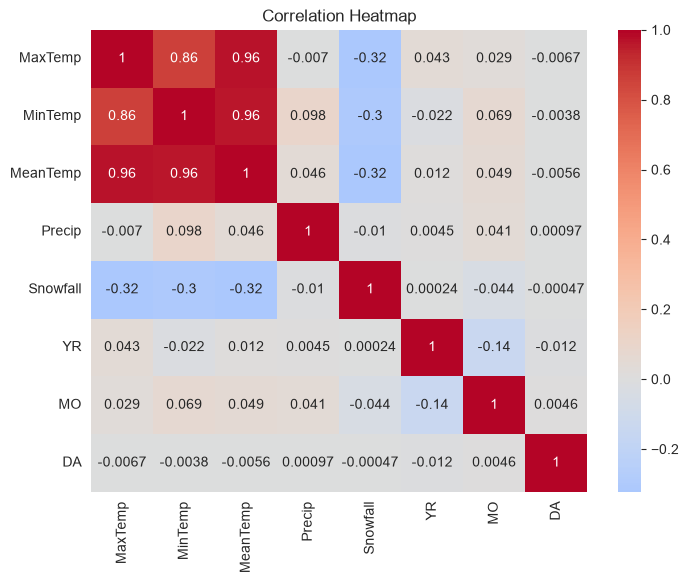

In [38]:
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [39]:
# Select features (X) and target (y)
# We will use MinTemp and MeanTemp to predict MaxTemp
X = df_clean[['MinTemp', 'MeanTemp']]
y = df_clean['MaxTemp']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (101359, 2)
Target shape: (101359,)


In [40]:
# Split the data (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 70951
Testing set size: 30408


In [41]:
# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model trained successfully!
Coefficients: [-0.86773639  1.85658007]
Intercept: 0.894957408399204


In [42]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error (RMSE):", round(rmse, 3))
print("R² Score:", round(r2, 3))

Root Mean Squared Error (RMSE): 1.027
R² Score: 0.985


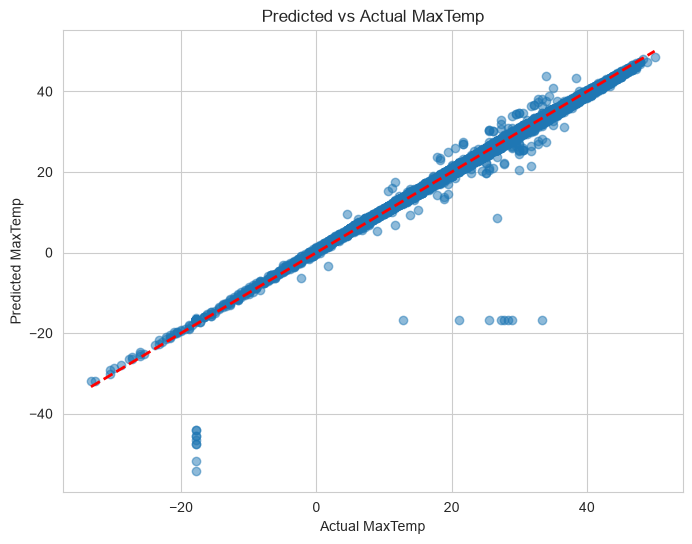

In [43]:
# Plot predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual MaxTemp')
plt.ylabel('Predicted MaxTemp')
plt.title('Predicted vs Actual MaxTemp')
plt.show()

In [46]:
print("RMSE:", round(rmse, 3))
print("R² Score:", round(r2, 3))

RMSE: 1.027
R² Score: 0.985
